In [1]:
!pip install nbformat

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

# Moving Average

_Moving Average_ (MA) is an indicator that constantly describes the average price over a period. It's also called _rolling average_. The mean over the last $k$ data points can be calculated as:

$\displaystyle {\begin{aligned}{\textit {SMA}}_{k}={\frac {p_{n-k+1}+p_{n-k+2}\cdots +p_{n}}{k}}={\frac {1}{k}}\sum _{i=n-k+1}^{n}p_{i}\end{aligned}}$

Intuitively, the value for a 3 days moving average in a given date $t$ is computed by simply calculating the average of the previous 3 values: $(t + t_{-1} + t_{-2}) / 3$.

Luckily, Pandas offers us the `.rolling()` function, that accepts the number of days to use:

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
prices = pd.read_csv("./data/prices.csv", index_col=[0,1], parse_dates=[1])

def stock_prices(ticker):
  return prices.loc[ticker].copy()

msft = stock_prices('msft')
ma50 = msft.Close.rolling(50).mean()
ma200 = msft.Close.rolling(200).mean()

`ma50` is a Series with all the computed moving average values

In [3]:
ma50.tail(4)

Date
2022-06-28    266.840599
2022-06-29    266.435399
2022-06-30    265.865999
2022-07-01    265.330399
Name: Close, dtype: float64

Using `ma50` and `ma200`, we can plot them to observe the trends over time. Lines should follow the main price values, but you should observe a more _soft_ reactions to price changes.

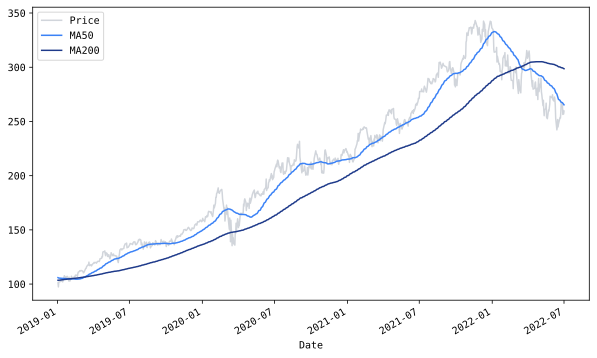

In [4]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = "monospace"

ig, ax = plt.subplots(figsize=(10,6))

msft.Close['2019':].plot(color='#D1D5DB', label="Price")
ma50['2019':].plot(color='#3B82F6', label="MA50")
ma200['2019':].plot(color='#1E3A8A', label="MA200")
plt.legend()
plt.show()

### Exercise 5.1

Read 2019 data for `aapl` and compute the moving average for the last 50 days using Spark.

### Exercise 5.2

Compute the same MA20, but this time by using [the Pandas API for Spark](https://databricks.com/blog/2021/10/04/pandas-api-on-upcoming-apache-spark-3-2.html). 

There could be a warning message like this one: _No Partition Defined for Window operation_. What does it mean?

## Exponential Moving Average (EMA)

A variation of this is to use the _Exponential Moving Average (EMA)_, that gives more weight to recent prices. SMA represent the average of prices in a timespan, and are better suited to identify "resistance" levels. In contrast, EMA has less lag and is therefore more sensitive to recent prices.

${ewm}(α)=(1−α)⋅{emw}_{t-1}+α⋅x_t$

Where $x_t$ is the price value as of today and ${emw}_{t-1}$ the EMA value from yesterday.

EMA is calculated using a smoothing or decay factor $\alpha$ that determines the weight given to the current period's value. The smoothing factor is a value between 0 and 1. A bigger smoothing factor gives more weight to recent data, making the EMA more responsive to recent price changes. Conversely, a smaller smoothing factor places more weight on older data, resulting in a smoother and slower-moving EMA.

$\alpha$ is typically calculated as $\alpha = 2 / (N + 1)$, where $N$ represents the number of periods or time intervals used in the EMA calculation.

Pandas offers us the [ewm](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ewm.html) function to calculate the exponentially weighted windows:

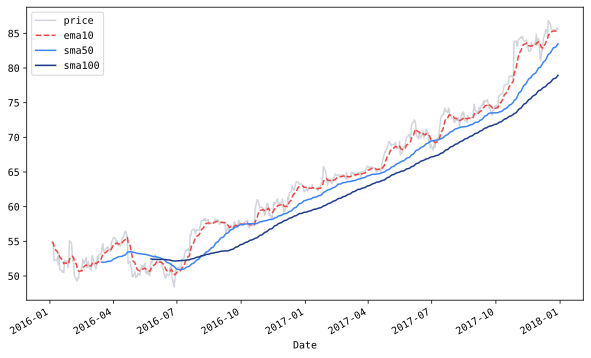

In [5]:
msft_2016 = msft['2016':'2017']
ema10 = msft_2016.Close.ewm(span=10, adjust=False).mean()
sma50 = msft_2016.Close.rolling(50).mean()
sma100 = msft_2016.Close.rolling(100).mean()

ig, ax = plt.subplots(figsize=(10,6))

msft_2016.Close.plot(ax=ax, color='#D1D5DB', label="price")
ema10.plot(ax=ax, color='#EF4444', linestyle="--", label="ema10")
sma50.plot(ax=ax, color='#3B82F6', label="sma50")
sma100.plot(ax=ax, color='#1E3A8A', label="sma100")
plt.legend()
plt.show()

One interesting thing about `ewm` is that it supports incremental updates. To use it, you have to call the `online` method right after `ewm` and that would return an object that allows to update the data with new data points.

In [6]:
import numba
online_ema10 = msft_2016.Close.ewm(span=10, adjust=False).online()
online_ema10.mean().tail(2)

Date
2017-12-28    85.460432
2017-12-29    85.474899
Name: Close, dtype: float64

In [7]:
online_ema10.mean(update=pd.Series([86.0]))

0    85.570372
dtype: float64

## MACD

There's another indicator called _Moving Average Convergence/Divergence Oscillator (MACD)_. It's calculated by getting two moving averages and substracting the longer moving average by the shorter one. In the calculated MCDA below, negative MACD values indicate that the 12-day EMA is below the 26-day EMA.

In [8]:
ema12 = msft_2016.Close.ewm(span=12, adjust=False).mean()
ema26 = msft_2016.Close.ewm(span=26, adjust=False).mean()
macd = ema12 - ema26
macd

Date
2016-01-04    0.000000
2016-01-05    0.019943
2016-01-06   -0.044431
2016-01-07   -0.244333
2016-01-08   -0.385402
                ...   
2017-12-22    0.918154
2017-12-26    0.867302
2017-12-27    0.842306
2017-12-28    0.813922
2017-12-29    0.768049
Name: Close, Length: 503, dtype: float64

Additionally, we can calculate a _signal line_ that would identify events on the MACD when both lines cross. When signal line is below the MACD, things are improving over time.

<Axes: xlabel='Date'>

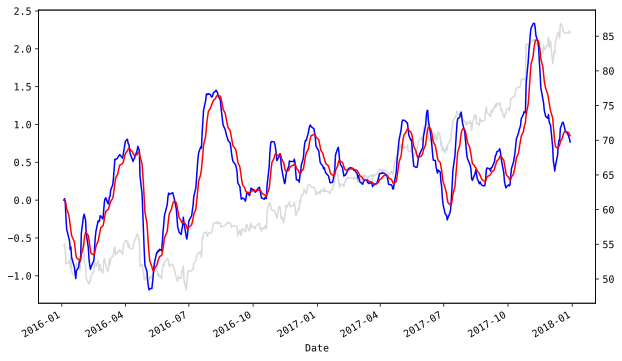

In [9]:
signal = macd.ewm(span=9, adjust=False).mean()

fig, ax = plt.subplots(figsize=(10,6))
msft_2016.Close.plot(ax=ax, color='#374151', alpha=0.2, secondary_y=True)
macd.plot(ax=ax, color='blue')
signal.plot(ax=ax, color='red')

---

### Exercise 5.1

Plot the MACD histogram as showed in the slide.

---

In [13]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# =========================
# 1. Cargar datos
# =========================
# Obtenemos los datos de MSFT y reseteamos el índice para que 'Date' sea una columna
df = stock_prices('msft').reset_index()

# Ordenamos por fecha para asegurar que los cálculos de ventana móvil sean correctos
df = df.sort_values("Date")

# Cogemos solo el año 2022
df = df[df["Date"].dt.year == 2022].copy()

# =========================
# 2. Calcular indicadores
# =========================
# sma1 = media móvil simple de 20 periodos
# sma2 = media móvil simple de 50 periodos
df["sma1"] = df["Close"].rolling(window=20).mean()
df["sma2"] = df["Close"].rolling(window=50).mean()

# hgm3: Calculamos la diferencia entre ambas SMAs (Histograma de convergencia/divergencia simple)
df["hgm3"] = df["sma1"] - df["sma2"]

# =========================
# 3. Crear figura con 2 paneles
# =========================
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    row_heights=[0.70, 0.30],
    vertical_spacing=0.03,
    subplot_titles=("Gráfico de Velas", "Indicadores (SMA20, SMA50 y Diferencia)")
)

# =========================
# 4. Gráfico de velas arriba
# =========================
fig.add_trace(
    go.Candlestick(
        x=df["Date"],
        open=df["Open"],
        high=df["High"],
        low=df["Low"],
        close=df["Close"],
        name="Precio MSFT"
    ),
    row=1,
    col=1
)

# =========================
# 5. Indicadores abajo
# =========================
fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df["sma1"],
        mode="lines",
        name="SMA20",
        line=dict(color='blue')
    ),
    row=2,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=df["Date"],
        y=df["sma2"],
        mode="lines",
        name="SMA50",
        line=dict(color='orange')
    ),
    row=2,
    col=1
)

fig.add_trace(
    go.Bar(
        x=df["Date"],
        y=df["hgm3"],
        name="HGM3 (SMA20-SMA50)",
        marker_color='gray',
        opacity=0.5
    ),
    row=2,
    col=1
)

# =========================
# 6. Ajustes visuales
# =========================
fig.update_layout(
    title="Análisis Técnico MSFT: Velas e Indicadores de Media Móvil",
    xaxis_rangeslider_visible=False,
    height=800,
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.update_yaxes(title_text="Precio (USD)", row=1, col=1)
fig.update_yaxes(title_text="Valor Indicador", row=2, col=1)

fig.show()
